In [13]:
import fastf1
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# --- 1. 설정 및 데이터 로드 ---
EVENT = 'Japanese Grand Prix'
YEAR = 2023
SESSION = 'R'
CACHE_DIR = '../fastf1_cache'
DIST_POINTS = 1000  # 리샘플링 포인트 수

fastf1.Cache.enable_cache(CACHE_DIR)
session = fastf1.get_session(YEAR, EVENT, SESSION)
session.load()

print(f"Session Loaded: {YEAR} {EVENT} - {SESSION}")

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '2

Session Loaded: 2023 Japanese Grand Prix - R


In [9]:
# --- 2. [핵심] Race Preprocessing for Dataset B & C ---

# 전체 드라이버의 랩 데이터를 가져옵니다.
race_laps = session.laps.pick_wo_box().pick_track_status('1').pick_accurate().copy()

# 필요 없는 컬럼 제거 및 정렬 준비 (가벼운 처리를 위해)
# 같은 LapNumber 내에서 Position 순으로 정렬 (1위, 2위, 3위... 순서대로 줄세우기)
race_laps = race_laps.sort_values(by=['LapNumber', 'Position'])

# 1. GapToAhead: 내 시간 - 앞차 시간 (같은 랩)
# 그룹화: LapNumber (각 랩 별로 계산해야 함)
race_laps['GapToAhead'] = race_laps.groupby('LapNumber')['Time'].diff().dt.total_seconds()

# 2. GapToBehind: 뒷차 시간 - 내 시간
# diff(-1)은 (현재 - 다음)이므로 부호를 바꿈. 혹은 shift(-1) 사용
race_laps['GapToBehind'] = race_laps.groupby('LapNumber')['Time'].diff(-1).dt.total_seconds().abs()

# NaN 처리: 
# 1위는 앞차가 없으므로 GapToAhead = 무한대(Clean) 혹은 매우 큰 값 처리
# 꼴등은 뒷차가 없으므로 GapToBehind = 무한대 처리
race_laps['GapToAhead'] = race_laps['GapToAhead'].fillna(999.0)
race_laps['GapToBehind'] = race_laps['GapToBehind'].fillna(999.0)

# --- Dataset Separation Logic ---

# Battle Condition (Dirty Air): 앞뒤 1.5초 이내
battle_mask = (race_laps['GapToAhead'] <= 1.5) | (race_laps['GapToBehind'] <= 1.5)

# Dataset C: Battle (Dirty Air)
ds_c_laps = race_laps[battle_mask].copy()
ds_c_laps['Scenario'] = 'C_Battle'

# Dataset B: Clean Air (Pure Pace) -> 학습용(Training)
ds_b_laps = race_laps[~battle_mask].copy()
ds_b_laps['Scenario'] = 'B_Clean'

print(f"Total Laps: {len(race_laps)}")
print(f"Dataset B (Clean Air) Laps: {len(ds_b_laps)} (Training Target)")
print(f"Dataset C (Battle) Laps: {len(ds_c_laps)} (Test/Analysis Target)")




Total Laps: 686
Dataset B (Clean Air) Laps: 461 (Training Target)
Dataset C (Battle) Laps: 225 (Test/Analysis Target)


In [7]:
# --- 3. Telemetry Processing Functions (기존 로직 유지) ---

def calculate_slip_delta(telemetry_df):
    # (이전과 동일한 로직: Gear Ratio 기반 SLIP_DELTA 계산)
    baseline_data = telemetry_df[telemetry_df['nGear'] > 0]
    gear_ratios = {}
    for gear in baseline_data['nGear'].unique():
        gear_slice = baseline_data[baseline_data['nGear'] == gear]
        valid_rpm = gear_slice[gear_slice['RPM'] > 0]
        if len(valid_rpm) > 0:
            gear_ratios[gear] = (valid_rpm['Speed'] / valid_rpm['RPM']).mean()
            
    telemetry_df['Estimated_Speed'] = telemetry_df.apply(
        lambda row: row['RPM'] * gear_ratios.get(row['nGear'], 0), axis=1
    )
    telemetry_df['SLIP_DELTA'] = telemetry_df['Estimated_Speed'] - telemetry_df['Speed']
    return telemetry_df

def process_laps_to_tensor(laps_df, dist_points=200):
    """
    필터링된 Laps DataFrame을 받아 Telemetry를 추출하고 Resampling하여 통합 DataFrame 반환
    """
    processed_laps = []
    
    # 진행 상황 표시를 위해 enumerate 사용
    print(f"Processing {len(laps_df)} laps...")
    
    for i, (idx, lap) in enumerate(laps_df.iterrows()):
        try:
            # 1. Telemetry 로드
            telemetry = lap.get_telemetry()
            
            # 2. Distance Interpolation (Resampling)
            total_dist = telemetry['Distance'].max()
            new_dist = np.linspace(0, total_dist, dist_points)
            
            cols_to_interp = ['Speed', 'RPM', 'Throttle', 'nGear', 'DRS']
            new_data = {'Distance': new_dist}
            
            for col in cols_to_interp:
                new_data[col] = np.interp(new_dist, telemetry['Distance'], telemetry[col])
            
            new_data['Brake'] = np.interp(new_dist, telemetry['Distance'], telemetry['Brake'].astype(float))
            
            resampled_df = pd.DataFrame(new_data)
            
            # 3. Feature Engineering
            resampled_df = calculate_slip_delta(resampled_df)
            
            # 4. Context Features
            resampled_df['TyreLife'] = lap['TyreLife']
            resampled_df['LapNumber'] = lap['LapNumber']
            resampled_df['Compound_SOFT'] = 1 if lap['Compound'] == 'SOFT' else 0
            resampled_df['Compound_MEDIUM'] = 1 if lap['Compound'] == 'MEDIUM' else 0
            resampled_df['Compound_HARD'] = 1 if lap['Compound'] == 'HARD' else 0
            resampled_df['Driver'] = lap['Driver'] # 나중에 분석용으로 드라이버 태그 추가
            
            processed_laps.append(resampled_df)
            
        except Exception as e:
            continue
            
    if not processed_laps:
        return None
        
    return pd.concat(processed_laps, ignore_index=True)

In [10]:
# --- 4. 데이터 생성 및 스케일링 ---

# Dataset B (Clean Air) 만 처리하여 학습 데이터로 사용
# (Top 10 드라이버만 필터링하고 싶다면 여기서 필터 추가 가능)
TARGET_DRIVERS = ['VER', 'NOR', 'PIA', 'LEC', 'HAM', 'SAI', 'RUS', 'ALO', 'OCO', 'GAS']
training_laps = ds_b_laps[ds_b_laps['Driver'].isin(TARGET_DRIVERS)]

print("Extracting Telemetry for Dataset B (Clean Air)...")
full_dataset_b = process_laps_to_tensor(training_laps, dist_points=DIST_POINTS)

# Feature Columns 정의
feature_cols = [
    'Speed', 'RPM', 'Throttle', 'Brake', 'nGear', 'DRS', 
    'SLIP_DELTA', 
    'TyreLife', 'LapNumber', 'Compound_SOFT', 'Compound_MEDIUM', 'Compound_HARD'
]

# Scaling
scaler = MinMaxScaler()
full_dataset_b[feature_cols] = scaler.fit_transform(full_dataset_b[feature_cols])

# Tensor 변환
num_samples = len(full_dataset_b) // DIST_POINTS
X_data = full_dataset_b[feature_cols].values[:num_samples * DIST_POINTS]
X_reshaped = X_data.reshape(num_samples, DIST_POINTS, len(feature_cols))

tensor_X = torch.FloatTensor(X_reshaped).to('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Training Tensor Shape: {tensor_X.shape}") 
# (Batch_Size, Sequence_Length, Num_Features)


Extracting Telemetry for Dataset B (Clean Air)...
Processing 295 laps...
Training Tensor Shape: torch.Size([295, 1000, 12])


Start Training on Dataset B...


 20%|██        | 10/50 [04:02<17:26, 26.15s/it]

Epoch [10/50] Loss: 0.038208


 40%|████      | 20/50 [08:59<14:41, 29.37s/it]

Epoch [20/50] Loss: 0.033555


...

Epoch [30/50] Loss: 0.032382


 80%|████████  | 40/50 [19:22<04:58, 29.84s/it]

Epoch [40/50] Loss: 0.035333


100%|██████████| 50/50 [25:18<00:00, 30.36s/it]

Epoch [50/50] Loss: 0.032239


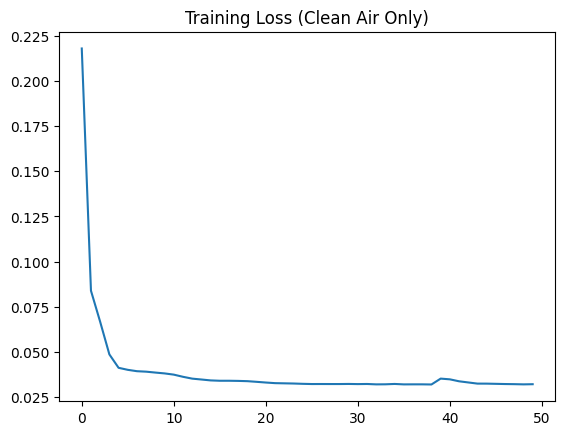

In [14]:
# --- 5. 모델 학습 (LSTM Autoencoder) ---
# (이전 코드와 동일, 데이터만 tensor_X로 사용)

dataset = TensorDataset(tensor_X, tensor_X)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=128): # Embedding Dim 늘림
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.encoder_lstm = nn.LSTM(n_features, embedding_dim, batch_first=True)
        self.decoder_lstm = nn.LSTM(embedding_dim, embedding_dim, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder_lstm(x)
        x_repeated = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_output, _ = self.decoder_lstm(x_repeated)
        x_reconstructed = self.output_layer(decoder_output)
        return x_reconstructed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMAutoencoder(seq_len=DIST_POINTS, n_features=len(feature_cols)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Start Training on Dataset B...")
NUM_EPOCHS = 50
loss_history = []

model.train()
for epoch in tqdm(range(NUM_EPOCHS)):
    epoch_loss = 0
    for batch_x, _ in dataloader:
        output = model(batch_x)
        loss = criterion(output, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.6f}")

plt.plot(loss_history)
plt.title("Training Loss (Clean Air Only)")
plt.show()

In [15]:
import joblib
import os

# 저장할 경로 설정
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, 'f1_lstm_autoencoder_v1.pth')
SCALER_PATH = os.path.join(SAVE_DIR, 'f1_scaler_v1.pkl')

# 1. 모델 체크포인트 딕셔너리 생성
# 나중에 모델을 다시 빌드할 때 필요한 정보(input size 등)를 'config'에 담습니다.
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': avg_loss,
    'config': {
        'seq_len': DIST_POINTS,      # 200
        'n_features': len(feature_cols), # Feature 개수
        'embedding_dim': 128         # 히든 레이어 크기
    }
}

# 2. 모델 및 학습 정보 저장 (PyTorch)
torch.save(checkpoint, MODEL_PATH)
print(f"Model checkpoint saved at: {MODEL_PATH}")

# 3. 스케일러 저장 (Scikit-Learn) -> 매우 중요!
# 이걸 안 하면 나중에 새 데이터를 0~1로 똑같이 못 바꿉니다.
joblib.dump(scaler, SCALER_PATH)
print(f"Scaler saved at: {SCALER_PATH}")

Model checkpoint saved at: models\f1_lstm_autoencoder_v1.pth
Scaler saved at: models\f1_scaler_v1.pkl


In [ ]:
import torch
import joblib
import torch.nn as nn

# --- 0. 모델 클래스 정의 (저장했던 코드와 동일해야 함) ---
class LSTMAutoencoder_v1(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=128):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.encoder_lstm = nn.LSTM(n_features, embedding_dim, batch_first=True)
        self.decoder_lstm = nn.LSTM(embedding_dim, embedding_dim, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder_lstm(x)
        x_repeated = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_output, _ = self.decoder_lstm(x_repeated)
        x_reconstructed = self.output_layer(decoder_output)
        return x_reconstructed

# --- 1. 파일 경로 설정 ---
SAVE_DIR = 'saved_models'
MODEL_PATH = os.path.join(SAVE_DIR, 'f1_lstm_autoencoder_v1.pth')
SCALER_PATH = os.path.join(SAVE_DIR, 'f1_scaler_v1.pkl')

# --- 2. 불러오기 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# (1) 스케일러 로드
loaded_scaler = joblib.load(SCALER_PATH)
print("Scaler loaded.")

# (2) 체크포인트 로드
checkpoint = torch.load(MODEL_PATH, map_location=device)

# (3) Config를 이용해 모델 구조 초기화 (하드코딩 방지)
config = checkpoint['config']
loaded_model = LSTMAutoencoder(
    seq_len=config['seq_len'],
    n_features=config['n_features'],
    embedding_dim=config['embedding_dim']
).to(device)

# (4) 가중치 덮어씌우기
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval() # 평가 모드로 전환 (Dropout 등 비활성화)

print(f"Model loaded from epoch {checkpoint['epoch']} with loss {checkpoint['loss']:.4f}")